# 1     Pre-Setting, Imports and Data Loading
## 1.1 Modules

In [1]:
from tokenize import group

# ======================= Module Imports ============================= #

# ========== Base Modules
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import CLIPProcessor, CLIPModel
from datetime import datetime
import numpy as np
import os
from pathlib import Path
from my_dataset import Flickr8kDataset
from torchvision import transforms # for image transformations
import pandas as pd # for data handling
from PIL import Image # for image processing
import matplotlib.pyplot as plt # for visualization

import re # for regex operations to analyze captions
from collections import Counter # to count word frequencies



/opt/miniconda3/envs/ADL_multimodal-retrieval/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# helperfunctions

# find project root
def find_project_root(start: Path = Path.cwd()):
    """Find the project root directory by looking for common markers."""
    # look for common project markers and return the first match
    for p in [start] + list(start.parents):
        if (p / 'data').exists() or (p / '.git').exists() or (p / 'pyproject.toml').exists():
            return p.resolve()
    return Path.cwd().resolve()

# compile model filename
def compile_filename(device, batch, epochs, lr, description):
    today = datetime.now().strftime("%Y%m%d")
    file_name = f"{today}_clip_{device}_bs{batch}_ep{epochs}_lr{lr}_{description}.pth"
    return file_name



## 1.2 Funcitonality Pre-settings

In [3]:
# Define dynamic paths
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    # fallback for Jupyter notebooks
    PROJECT_ROOT = find_project_root()

# PROJECT_ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data"
IMG_DIR = DATA_DIR / "Images"
CAPTIONS_FILE = DATA_DIR / "flickr8k_captions.csv"
RUNS_DIR = PROJECT_ROOT / "runs"


# Finetuning flag
finetuning = True

# model saving flag
save_model = True

# Subset flag for faster testing
use_subset = True
subset_size = 500  # Number of samples in subset
batch_size = 32



## 1.3 Data Loading


In [4]:
# Load Dataset
# CSV laden
captions = pd.read_csv(CAPTIONS_FILE, sep=";", engine="python")

# # Preprocessing if necessary
# preprocess = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
# ])

# length of dataset
dataset_length = len(captions)

# show first 5 entries
captions.head()


,filename,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


# 2 Data Analysis and Visualization
## 2.1 Descrition

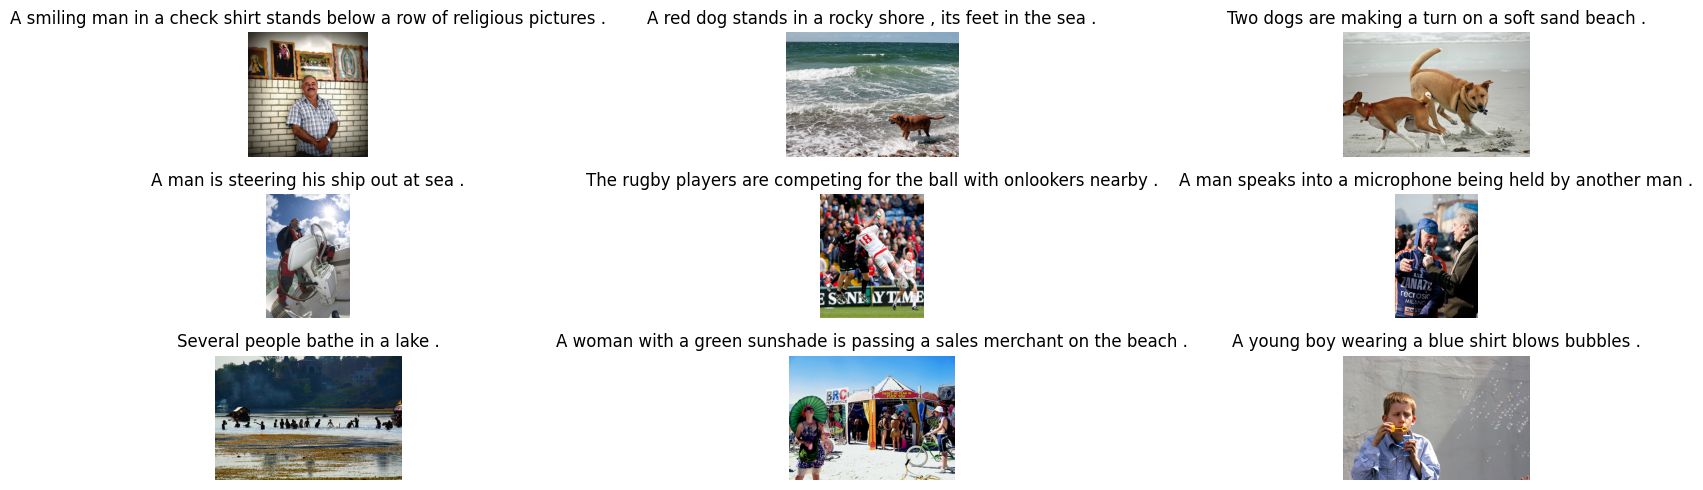

In [5]:
# plot some random images with captions as example
fig, axes = plt.subplots(3, 3, figsize=(20, 5))

# random seed
# np.random.seed(42)

# plot random samples
for ax in axes.ravel():
    row = captions.sample(1).iloc[0]
    img = Image.open(os.path.join(IMG_DIR, row['filename']))
    ax.imshow(img)
    ax.set_title(row['caption'])
    ax.axis('off')

plt.tight_layout()
plt.show()


## 2.2 Image and Caption analysis

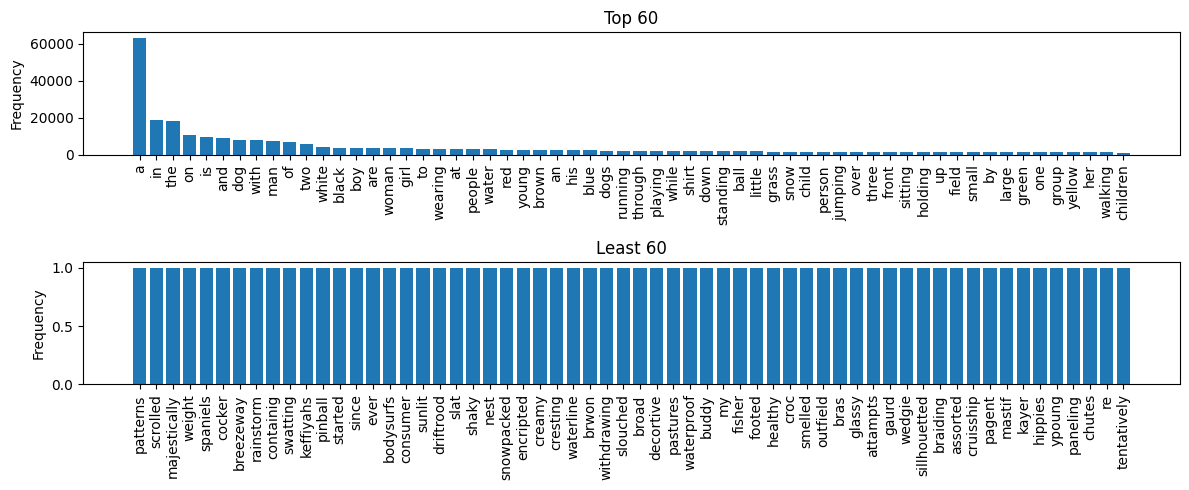

In [6]:
# combine all captions into one large text
text = " ".join(captions["caption"].astype(str)).lower()

# extract words using regex
words = re.findall(r"\b\w+\b", text)

# count word frequencies
freq = Counter(words)

# get the 30 most common and 30 least common words
top30 = freq.most_common(60)
least30 = freq.most_common()[:-61:-1]

# print(top30)

# Plot the results
fig, axes = plt.subplots(2, 1, figsize=(12, 5))

# top: Top 30
axes[0].bar([w for w,_ in top30], [c for _,c in top30])
axes[0].set_title("Top 60")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis='x', rotation=90)

# bottom: Least 30
axes[1].bar([w for w,_ in least30], [c for _,c in least30])
axes[1].set_title("Least 60")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

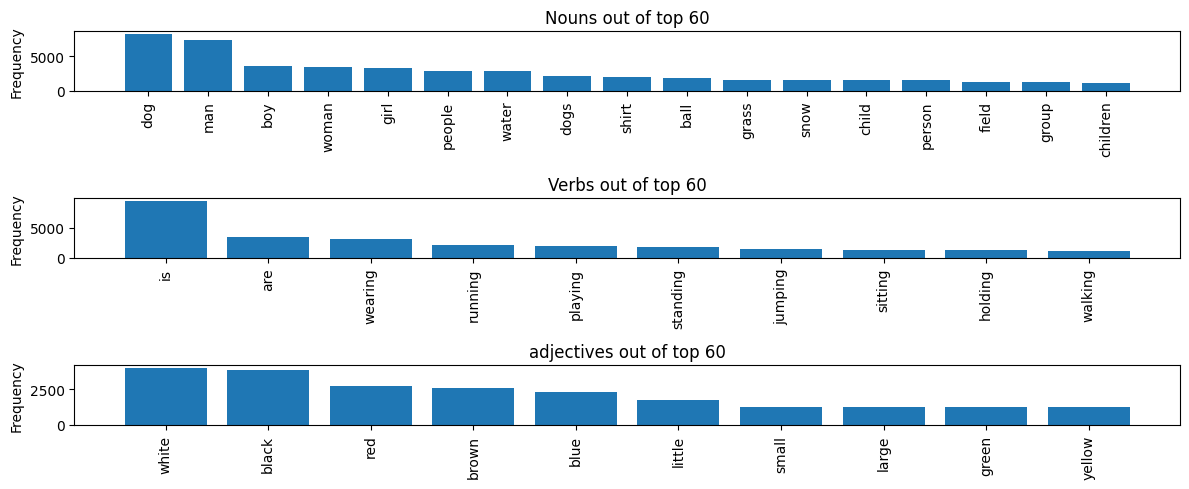

In [7]:
# closer look at nouns, verbs, adjectives in top 60 words
# manually categorized based on common English usage

# top 60 words categorized
top60_nouns = [('dog', 8138), ('man', 7274), ('boy', 3581), ('woman', 3402), ('girl', 3328), ('people', 2883), ('water', 2790), ('dogs', 2125), ('shirt', 1962), ('ball', 1783), ('grass', 1622), ('snow', 1547), ('child', 1545), ('person', 1542), ('field', 1283), ('group', 1218), ('children', 1156)]

top60_verbs = [('is', 9345), ('are', 3504), ('wearing', 3062), ('running', 2073), ('playing', 2008), ('standing', 1787), ('jumping', 1473), ('sitting', 1368), ('holding', 1324), ('walking', 1165)]

top60_adj = [('white', 3959), ('black', 3848), ('red', 2691), ('brown', 2578), ('blue', 2279), ('little', 1768), ('small', 1278), ('large', 1236), ('green', 1234), ('yellow', 1217)]

# Plot the results
fig, axes = plt.subplots(3, 1, figsize=(12, 5))

# top: Top 30
axes[0].bar([w for w,_ in top60_nouns], [c for _,c in top60_nouns])
axes[0].set_title("Nouns out of top 60")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis='x', rotation=90)

# bottom: Least 30
axes[1].bar([w for w,_ in top60_verbs], [c for _,c in top60_verbs])
axes[1].set_title("Verbs out of top 60")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis='x', rotation=90)

# bottom: Least 30
axes[2].bar([w for w,_ in top60_adj], [c for _,c in top60_adj])
axes[2].set_title("adjectives out of top 60")
axes[2].set_ylabel("Frequency")
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [8]:
# number of unique words
num_unique_words = len(freq)
print(f"Number of unique words in captions: {num_unique_words}")

Number of unique words in captions: 8488


In [9]:
# average caption length
avg_caption_length = sum(len(caption.split()) for caption in captions["caption"]) / dataset_length
print(f"Average caption length: {avg_caption_length:.2f} words")


Average caption length: 11.78 words


Average image size: 457.87 x 397.25 pixels


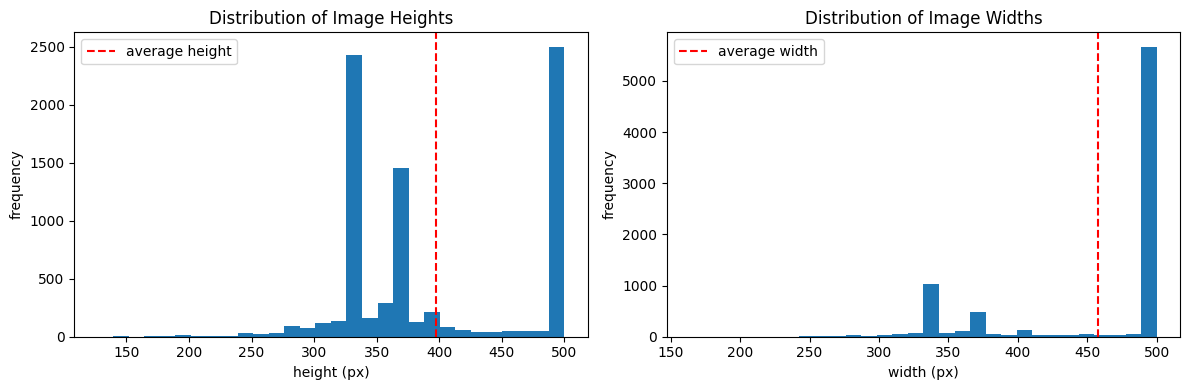

In [10]:
# image proerties
image_sizes = []
for filename in captions["filename"].unique():
    img_path = os.path.join(IMG_DIR, filename)
    with Image.open(img_path) as img:
        image_sizes.append(img.size)
widths, heights = zip(*image_sizes)
avg_width = sum(widths) / len(widths)
avg_height = sum(heights) / len(heights)
print(f"Average image size: {avg_width:.2f} x {avg_height:.2f} pixels")


fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(heights, bins=30)
ax[0].axvline(avg_height, linestyle="--", color = 'red')
ax[0].set_xlabel("height (px)")
ax[0].set_ylabel("frequency")
ax[0].set_title("Distribution of Image Heights")
ax[0].legend(["average height"])

ax[1].hist(widths, bins=30)
ax[1].axvline(avg_width, linestyle="--", color = 'red')
ax[1].set_xlabel("width (px)")
ax[1].set_ylabel("frequency")
ax[1].set_title("Distribution of Image Widths")
ax[1].legend(["average width"])

plt.tight_layout()
plt.show()


# 3 Data Preprocessing

## 3.1 Dataloader, Subset and Transformations

##

In [11]:
# dataloader with transformations and subset option
if use_subset:
    captions = captions.sample(n=subset_size, random_state=42).reset_index(drop=True)

# create new csv file for subset
subset_captions_file = DATA_DIR / f"flickr8k_captions_subset_{subset_size}.csv"
captions.to_csv(subset_captions_file, sep=";", index=False)
CAPTIONS_FILE = subset_captions_file


# dataloader
dataset = Flickr8kDataset(root_dir=str(IMG_DIR), captions_file=str(CAPTIONS_FILE))
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)  # set num_workers>0 for faster loading in non-Windows systems



# 4 Model Building and Training

## 4.1 Pretrained Model Loading

In [12]:
# load pretrained CLIP model and processor
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

# freez Encoder
for param in model.vision_model.parameters():
    param.requires_grad = False
for param in model.text_model.parameters():
    param.requires_grad = False

# optimizer and loss function and other parameters
loss_fn = nn.CrossEntropyLoss()
epochs = 1
lr = 1e-5

if finetuning:
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
else:
    optimizer = optim.AdamW(model.text_model.parameters(), lr=1e-5)


# move model to device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(DEVICE)
model.train()



Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,


## 4.2 Training Loop

In [14]:
def training_loop(model, dataloader, optimizer, loss_fn, processor, DEVICE, epochs=epochs):
    train_data = []

    for epoch in range(epochs):
        total_loss = 0
        loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for images, texts in loop:
            inputs = processor(text=texts, images=images, return_tensors="pt", padding=True).to(DEVICE)

            outputs = model(**inputs)
            logits_per_image = outputs.logits_per_image
            logits_per_text = outputs.logits_per_text

            ground_truth = torch.arange(len(images), device=DEVICE)
            loss_i = loss_fn(logits_per_image, ground_truth)
            loss_t = loss_fn(logits_per_text, ground_truth)
            loss = (loss_i + loss_t) / 2

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())
            train_data.append(total_loss)

        print(f"Epoch {epoch+1} — Avg Loss: {total_loss/len(loader):.4f}")

    filename = compile_filename(DEVICE, batch_size, epochs, lr, "test")
    filename = RUNS_DIR / filename

    if save_model:
        torch.save(model.state_dict(), filename)
        print(f"Model saved as <<{filename}>>")

training_loop(model, loader, optimizer, loss_fn, processor, DEVICE, epochs=epochs)

Epoch 1 — Avg Loss: 3.6226


RuntimeError: [enforce fail at inline_container.cc:664] . unexpected pos 227528512 vs 227528400


## 4.3 Hyperparameter Tuning

## 4.4 Saving the Model and export Data

# 5 Evaluation

# 6 Final Remarks